
# 🧠 **The `torch.nn` Module (PyTorch)**

## 📌 **What is `torch.nn`?**

The `torch.nn` module in PyTorch is a **core library** used to build neural networks.

👉 It helps you:

* Create neural network architectures easily
* Avoid writing everything from scratch
* Focus on **model design instead of low-level math**

---

## 🔑 **Why it is important**

Without `torch.nn`:

* You would manually define weights, gradients, loss, etc.

With `torch.nn`:

* You get **ready-made building blocks**:

  * Layers
  * Activation functions
  * Loss functions

---

# ⚙️ **Key Components of `torch.nn`**

---

## **1. Modules (Layers)**

### 🔹 `nn.Module`

* Base class for **all neural networks**
* Every custom model must inherit from it

```python
import torch.nn as nn

class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
```

---

### 🔹 Common Layers

* `nn.Linear` → Fully connected layer
* `nn.Conv2d` → Convolution layer (CNN)
* `nn.LSTM` → Recurrent layer (sequence data)

👉 Example:

```python
nn.Linear(10, 5)
```

---

## **2. Activation Functions**

Used to introduce **non-linearity** (VERY IMPORTANT)

### Common ones:

* `nn.ReLU()` → most used
* `nn.Sigmoid()` → binary output
* `nn.Tanh()` → centered output

👉 Why needed?
Without activation → model = **just linear equation**

---

## **3. Loss Functions**

Used to measure **how wrong the model is**

### Common losses:

* `nn.CrossEntropyLoss()` → classification
* `nn.MSELoss()` → regression
* `nn.NLLLoss()` → log-probability loss

👉 Example:

```python
loss_fn = nn.CrossEntropyLoss()
```

---

## **4. Container Modules**

Helps organize layers

### 🔹 `nn.Sequential`

* Stack layers easily

```python
model = nn.Sequential(
    nn.Linear(10, 20),
    nn.ReLU(),
    nn.Linear(20, 2)
)
```

---

## 🧠 **How everything connects (BIG PICTURE)**

```
Input → Layer → Activation → Layer → Output
                  ↓
               Loss
                  ↓
            Backpropagation
```

---

## 🚀 **Simple End-to-End Example**

```python
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(4, 10),
    nn.ReLU(),
    nn.Linear(10, 3)
)

loss_fn = nn.CrossEntropyLoss()

x = torch.randn(5, 4)
y = torch.tensor([0, 1, 2, 1, 0])

output = model(x)
loss = loss_fn(output, y)

loss.backward()
```

---



**Working code**

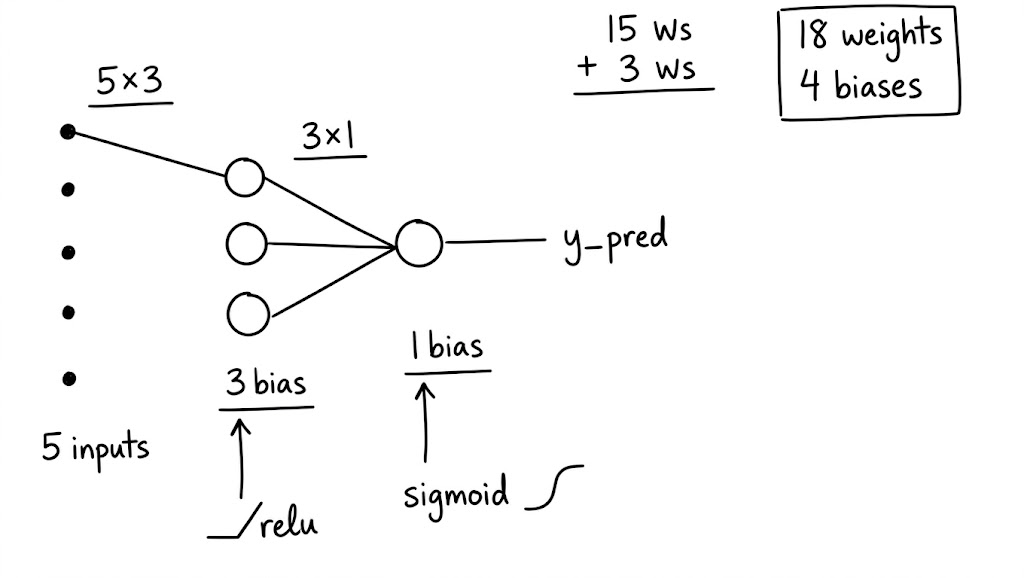

In [ ]:
import torch
import torch.nn as nn

class Model(nn.Module): # inherit from this class
  def __init__(self,num_features): # it defines the model and no data has passed yet
    super().__init__()
    self.linear1=nn.Linear(num_features,3)
    self.relu=nn.ReLU()
    self.linear2=nn.Linear(3,1)
    self.sigmoid=nn.Sigmoid()

  def forward(self,features): # t runs the model
    out=self.linear1(features)
    out=self.relu(out)
    out=self.linear2(out)
    out=self.sigmoid(out)
    return out

In [ ]:
#create Dataset
features=torch.rand(10,5)

#create Model
model=Model(num_features =features.shape[1])

#make predictions
output=model(features)  # internally it calls magic operatior __call__
                        # which mean forward is default call Model.forward(feature)

In [ ]:
output

tensor([[0.4003],
        [0.4003],
        [0.4003],
        [0.3973],
        [0.4054],
        [0.3908],
        [0.3880],
        [0.4003],
        [0.3875],
        [0.3897]], grad_fn=<SigmoidBackward0>)

In [ ]:
model.linear1.weight #it should have 15 weights

Parameter containing:
tensor([[-0.1561,  0.2312,  0.1361,  0.1574, -0.1380],
        [-0.1561, -0.2434, -0.0441,  0.1454, -0.0389],
        [-0.1805,  0.3845, -0.3037,  0.0858,  0.0962]], requires_grad=True)

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 3]                   18
├─ReLU: 1-2                              [10, 3]                   --
├─Linear: 1-3                            [10, 1]                   4
├─Sigmoid: 1-4                           [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

Can Stream line teh code in better way


In [ ]:
import torch
import torch.nn as nn

class Model(nn.Module): # inherit from this class
  def __init__(self,num_features): # it defines the model and no data has passed yet
    super().__init__()
    self.container=nn.Sequential( # it defines the sequential network/container
                                  #Stacks layers in order (one after another)
        nn.Linear(num_features,3),
        nn.ReLU(),
        nn.Linear(3,1),
        nn.Sigmoid())

  def forward(self,features): # t runs the model
    out=self.container(features)
    return out

In [ ]:
#create Dataset
features=torch.rand(10,5)

#create Model
model=Model(num_features =features.shape[1])

#make predictions
output=model(features)  # internally it calls magic operatior __call__
                        # which mean forward is default call Model.forward(feature)

In [ ]:
summary(model,(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Sequential: 1-1                        [10, 1]                   --
│    └─Linear: 2-1                       [10, 3]                   18
│    └─ReLU: 2-2                         [10, 3]                   --
│    └─Linear: 2-3                       [10, 1]                   4
│    └─Sigmoid: 2-4                      [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

# Solving the problem

In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


Load the data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')

In [ ]:
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)

# Train test Split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('diagnosis',axis=1),df['diagnosis'],test_size=0.2,random_state=42)



# Scaling the variable

In [ ]:
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train) # Fit used to learn the mean and standard deviation and transform applies the scalar formula (x-mu)/sigma
                                  #output is NumPy array
x_test=scalar.transform(x_test) # it uses the mean  and sigma created for learning dataset to transform test.

# Labeling the variable

In [ ]:
y_train=LabelEncoder().fit_transform(y_train) #label encoder assign the numbers 0,1,2 etc. if value has 3 values then it will assign 0,1,2 which creates ordinal data
                                            # one Hot encoder creates dummy variable
y_test=LabelEncoder().fit_transform(y_test)

In [ ]:
#Converting numpy to tensor
x_train_tensor=torch.from_numpy(x_train).float()
y_train_tensor=torch.from_numpy(y_train).float()
x_test_tensor=torch.from_numpy(x_test).float()
y_test_tensor=torch.from_numpy(y_test).float()


# Model Creation

In [ ]:
import torch
import torch.nn as nn

class Model(nn.Module): # inherit from this class
  def __init__(self,num_features): # it defines the model and no data has passed yet
    super().__init__()
    self.container=nn.Sequential( # it defines the sequential network/container
                                  #Stacks layers in order (one after another)
        nn.Linear(num_features,3),
        nn.ReLU(),
        nn.Linear(3,1),
        nn.Sigmoid())

  def forward(self,features): # t runs the model
    out=self.container(features)
    return out


# Hyper Parameter

In [ ]:
learning_rate=0.1
epoch=25

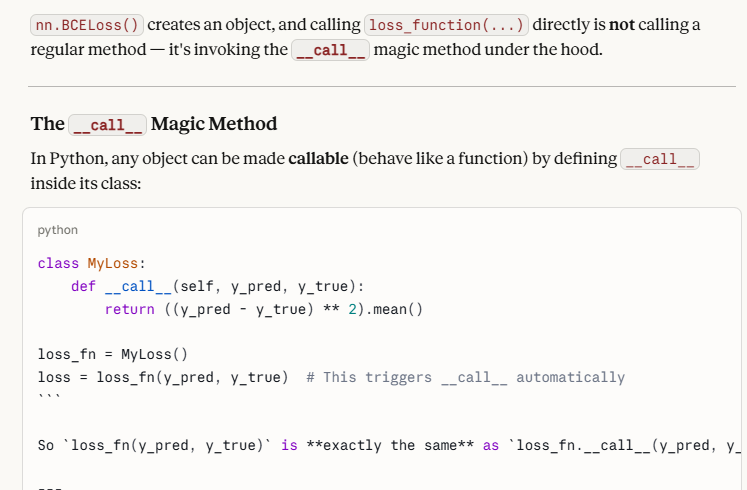

#Training Pipeline

In [ ]:
##Creating model

model=Model(x_train_tensor.shape[1])

#defining optimizer
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

# define loss function
loss_function = nn.BCELoss()

#creating a loop
for epoch in range(epoch):
  #forward pass
  y_pred=model(x_train_tensor)

  #loss function
  loss=loss_function(y_pred,y_train_tensor.reshape(-1,1))

  #Clear Gradient
  optimizer.zero_grad()

  # backward pass
  loss.backward()

  #Parameter Update
  optimizer.step()

  # print loss in each epoch
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')


NameError: name 'Model' is not defined

In [ ]:
with torch.no_grad():
  y_pred=model.forward(x_test_tensor)
  y_pred_r=(y_pred > 0.99).float()
  accuracy=(y_pred_r==y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')

Accuracy: 0.6228070259094238
